In [1]:
!nvidia-smi

Tue Apr 22 10:56:58 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.67                 Driver Version: 550.67         CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A6000               Off |   00000000:3B:00.0 Off |                  Off |
| 30%   43C    P8             26W /  300W |      29MiB /  49140MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import os, sys
# os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false" # Disable jax preallocation for memory debugging only
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import numpy as np
import xarray as xr
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from gofish import imagecube
from ruamel.yaml import YAML
from pathlib import Path
from tqdm.notebook import tqdm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from collections import OrderedDict
import tensorboardX
from flax.training import checkpoints

sys.path.insert(0, '../')
import visualization, sensor, grid, line_rte
import parametric_disk_old as parametric_disk
from network import shard
import network
from consts import *
import emcee
from functools import partial
import time
import visibilities_utils as vis_utils

def print_array_size_GB(array):
    num_bytes = array.size * array.dtype.itemsize
    print(f"{num_bytes / (1024**3):.4f} GB")
    
def pad_image_cube(cube, target_size=2048):
    nchan, npix, _ = cube.shape
    if npix > target_size:
        raise ValueError("Cube's dimensions are larger than target size; consider cropping instead.")
    
    pad_total = target_size - npix
    pad_before = pad_total // 2
    pad_after = pad_total - pad_before

    padded_cube = jnp.pad(cube, 
                          pad_width=((0, 0), (pad_before, pad_after), (pad_before, pad_after)),
                          mode='constant',
                          constant_values=0)
    return padded_cube

def render_cube_pinhole(ray_coords, pixel_area, disk_params, nd_co, temperature, velocity_az, bbox, freqs, nu0, obs_dir, molecular_table):
    ray_coords_sph = grid.cartesian_to_spherical(ray_coords)
    ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)

    # Interpolate dataset along the ray coordinates
    gas_nd = grid.interpolate_scalar(nd_co, ray_coords_polar, bbox)
    gas_t  = grid.interpolate_scalar(temperature, ray_coords_polar, bbox, cval=1e-10)
    gas_v_az = grid.interpolate_scalar(velocity_az, ray_coords_polar, bbox)
    gas_v = parametric_disk.azimuthal_velocity(ray_coords, gas_v_az)

    # Load molecular data from disk_params
    energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=molecular_table)
    _, a_ud, b_ud, b_du = line_rte.einstein_coefficients(
        energy_levels, radiative_transitions, transition=disk_params['transition']
    )
    n_up, n_dn = line_rte.n_up_down(
        gas_nd, gas_t, energy_levels, radiative_transitions, transition=disk_params['transition']
    )
    alpha_tot = line_rte.alpha_total_co(disk_params['v_turb'], gas_t)

    print(f'computing pinhole spectral cube for a total of {freqs.size} frequencies')
    images = line_rte.compute_spectral_cube_pmap(
        shard(freqs), gas_v, alpha_tot, n_up, n_dn,
        a_ud, b_ud, b_du, ray_coords, obs_dir, nu0, pixel_area
    )
    images = np.nan_to_num(images).reshape(freqs.size, *ray_coords.shape[:2])
    return images

def render_cube(ray_coords, pixel_area, disk, nd_co, temperature, velocity_az, bbox, freqs, nu0):
    ray_coords_sph = grid.cartesian_to_spherical(ray_coords)
    ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)
    
    # Interpolate dataset along the ray coordinates
    gas_nd = grid.interpolate_scalar(nd_co, ray_coords_polar, bbox)
    gas_t  = grid.interpolate_scalar(temperature, ray_coords_polar, bbox, cval=1e-10)
    gas_v_az = grid.interpolate_scalar(velocity_az, ray_coords_polar, bbox)
    gas_v = parametric_disk.azimuthal_velocity(ray_coords, gas_v_az)
    
    # Einstein coefficient for spontaneous emission from level u to level d
    energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=disk.molecule_table)
    _, a_ud, b_ud, b_du = line_rte.einstein_coefficients(energy_levels, radiative_transitions, transition=disk.transition)
    n_up, n_dn = line_rte.n_up_down(gas_nd, gas_t, energy_levels, radiative_transitions, transition=disk.transition)

    alpha_tot = line_rte.alpha_total_co(disk.v_turb, gas_t)

    # print('computing spectral cube for a total of {} frequencies'.format(freqs.size))
    images = line_rte.compute_spectral_cube_pmap(shard(freqs), gas_v, alpha_tot, n_up, n_dn, a_ud, b_ud, b_du, ray_coords, obs_dir, nu0, pixel_area)
    images = np.nan_to_num(images).reshape(freqs.size, *ray_coords.shape[:2])
    return images

def intensity_to_nchw(intensity, vmin=None, vmax=None, cmap='viridis', gamma=0.5):
    cm = plt.get_cmap(cmap)
    if vmin is None: vmin = np.min(intensity)
    if vmax is None: vmax = np.max(intensity)
    norm_images = np.flip(( (intensity - vmin) / (vmax - vmin) )**gamma, axis=-2)
    if intensity.ndim == 2:
        nchw_images = np.moveaxis(cm(norm_images)[...,:3], (0, 1, 2), (1, 2, 0))
    elif intensity.ndim == 3:
        nchw_images = np.moveaxis(cm(norm_images)[...,:3], (0, 1, 2, 3), (0, 2, 3, 1))
    return nchw_images

fov_as = 10.0                 # arcsecs
velocity_range = (2000, 10000) # m/s

data_path = '/scratch/ondemand28/len/data/radjax/MAPS/HD_163296_CO_220GHz.0.2arcsec.image.fits'
vlsr = 5760   # m/s
isotop_abundance = 1

# data_path = '../data/alma_highres/HD163296_13CO_beam0.20_100ms_3sigma.clean.image.cutout.fits'
# vlsr = 5770   # m/s
# isotop_abundance = 1/69
# 
# data_path = '../data/alma_highres/HD163296_C18O_beam0.20_100ms_3sigma.clean.image.cutout.fits'
# vlsr = 5750   # m/s
# isotop_abundance = 1/557

data_cube = imagecube(data_path, FOV=fov_as, velocity_range=velocity_range)
freqs = data_cube.velocity_to_restframe_frequency(vlsr=vlsr)
velocities = data_cube.velax
data = data_cube.data
x_sky, y_sky = np.meshgrid(data_cube.xaxis, data_cube.yaxis, indexing='xy')
nu0 = data_cube.nu0
npix = data_cube.nxpix
width_kms = (velocities[-1] - velocities[0]) / 1000.0
delta_v_ms = velocities[1] - velocities[0]
num_freqs = len(freqs)
data_dir = Path(data_path).parent
print('velocity resolution: {} m/s'.format(delta_v_ms))

beam = data_cube.beams_per_pix * sensor.beam(data_cube.dpix, data_cube.bmaj, data_cube.bmin, data_cube.bpa)

## TODO: Update with MCMC

disk = parametric_disk.DiskFlaherty(
    name='HD163296_CO(2-1)',
    q=-0.27,
    q_in=-0.57,
    r_break=70,
    log_r_c=2.3,
    v_turb=0.06,
    T_atm1=87.0,
    gamma=1.0,
    T_mid1=17.8,
    M_star=2.3*M_sun,
    r_in=11.0,
    M_gas=0.09*M_sun,
    co_abundance=1e-4 * isotop_abundance,
    N_dissoc=0.79*1.59e21,
    N_desorp=-np.inf,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    delta=1,
    transition=2,
    m_mol=2.37*m_h,
    molecule_table='../molecular_tables/molecule_12c16o.inp',
)

resolution = 500
z_min, z_max = 0, 200
r_min, r_max = disk.r_in, 800
z_disk, r_disk = jnp.meshgrid(jnp.linspace(z_min, z_max, resolution), jnp.linspace(r_min, r_max, resolution), indexing='ij')

temperature = disk.temperature_profile(z_disk, r_disk)
nd_h2 = parametric_disk.number_density_profile(z_disk, r_disk, temperature, disk.gamma, disk.r_in, 10**disk.log_r_c, disk.M_gas, disk.M_star, disk.m_mol)
velocity_az = disk.velocity(z_disk, r_disk, nd_h2, temperature)

# Compute the column integrated density N(h2) (units of 1/cm^2)
N_h2 = parametric_disk.surface_density(z_disk, nd_h2)
sigma_h2 = N_h2 * m_h

# Compute the relative abundance of co
abundance_co = disk.co_abundance_profile(N_h2, temperature)
nd_co = abundance_co * nd_h2

projection = sensor.PinholeProjection(
    name=disk.name,
    x_sky=x_sky,
    y_sky=y_sky,
    distance=122.0, 
    nray=100,
    incl=47.5,
    phi=0.0,
    posang=312.0,
    z_width=2*z_max,
    freqs=freqs
)
# Bounding box for interpolations
bbox_disk = jnp.array([(au*z_min, au*z_max), (au*r_min, au*r_max)])

fov_rad =  fov_as*arcsec                                # field of view 
fov = 2 * projection.distance*pc * np.tan(fov_rad/2.0)  # gives ~1708 [au] for 14as
pixel_area = (fov/npix)**2
ray_coords, obs_dir = sensor.pinhole_disk_projection(
    projection.x_sky, projection.y_sky, projection.distance, projection.nray, 
    projection.incl, projection.phi, projection.posang, projection.z_width
)

# Render spectral cube and convolve with gaussian beam
images = render_cube(ray_coords, pixel_area, disk, nd_co, temperature, -velocity_az, bbox_disk, freqs, nu0)
images_blurred = sensor.fftconvolve_vmap(images, beam)

# Add spectral blurring?
# images_spectral_blur = signal.convolve(images, hann, mode='same') / np.sum(hann)
# images_blurred = sensor.fftconvolve_vmap(images_spectral_blur, beam)

velocity resolution: 199.99999998061412 m/s


2025-04-22 03:33:33.228242: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version 12.6.77. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


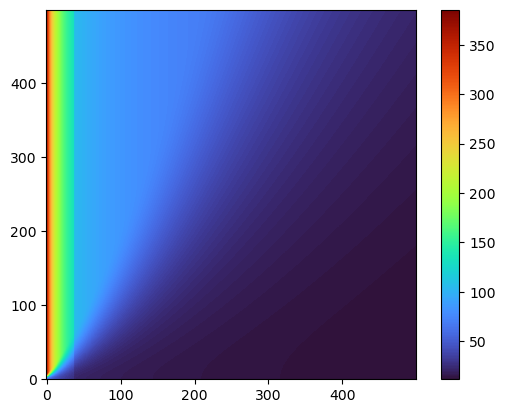

In [67]:
plt.imshow(temperature, origin='lower', cmap='turbo')
plt.colorbar()

# Neural temperature recovery with chi squared loss on T
## Generate sigma noise map

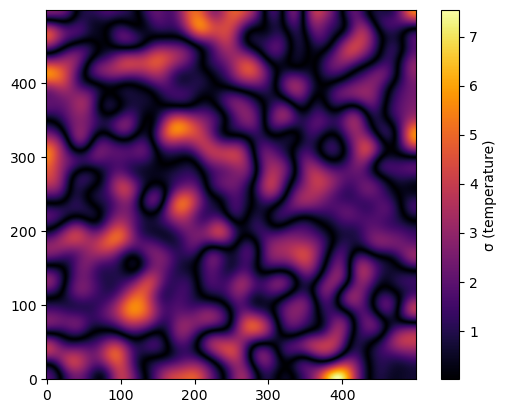

In [62]:
from scipy.ndimage import gaussian_filter

def make_matern_like_sigma_map(
    z_min, z_max, r_min, r_max, resolution,
    length_scale,   # ℓ in AU
    scale=0.1,      # desired rms amplitude
    sigma_floor=0.01,
    random_seed=42
):
    # 1) grid coords and pixel size
    zs = np.linspace(z_min, z_max, resolution)
    rs = np.linspace(r_min, r_max, resolution)
    Δz = (z_max - z_min)/(resolution-1)
    Δr = (r_max - r_min)/(resolution-1)
    # approximate isotropic pixel
    Δ = 0.5*(Δz + Δr)

    # 2) white noise
    rng = np.random.default_rng(random_seed)
    white = rng.standard_normal((resolution, resolution))

    # 3) Gaussian smoothing
    #    sigma (in pixels) = length_scale / Δ
    σ_pix = length_scale/Δ
    smooth = gaussian_filter(white, σ_pix, mode="reflect")

    # 4) rescale to unit‐variance then apply scale & floor
    smooth -= smooth.mean()
    smooth /= smooth.std()
    sigma_map = sigma_floor + scale * np.abs(smooth)

    return sigma_map

# usage:
sigma_map = make_matern_like_sigma_map(
    z_min, z_max, r_min, r_max, resolution=500,
    length_scale=15.0,
    scale=2,
    sigma_floor=0.01
)

plt.imshow(sigma_map, origin="lower",
           cmap="inferno")
plt.colorbar(label="σ (temperature)")

In [114]:
from functools import partial
import flax
from flax.training import checkpoints
from datetime import datetime

# ──────────────────────────────────────────────────────────────────────
# 1) Simplified temperature-only “dataset”
# ──────────────────────────────────────────────────────────────────────
# z_disk, r_disk: (resolution, resolution) meshes
# temperature:       same shape, from your parametric disk
# sigma_map:        same shape, from make_matern_like_sigma_map(...)
coords = jnp.stack((z_disk, r_disk), axis=-1).reshape(-1,2)  # (N,2)
temp_gt = temperature.reshape(-1)                            # (N,)
sigma  = sigma_map.reshape(-1)                              # (N,)

# ──────────────────────────────────────────────────────────────────────
# 2) A toy “image_prediction” that just runs the MLP
# ──────────────────────────────────────────────────────────────────────
class ToyTemperatureField:
    def __init__(self, coords, shape):
        self.coords = coords      # flattened (N,2)
        self.shape  = shape       # (resolution, resolution)
    @partial(jax.jit, static_argnums=0)
    def predict(self, params, apply_fn):
        # apply_fn expects {'params': params}, coords
        T_pred = apply_fn({'params': params}, self.coords)  # (N,)
        return T_pred

# ──────────────────────────────────────────────────────────────────────
# 3) Toy loss and gradient step
# ──────────────────────────────────────────────────────────────────────
def loss_fn_toy(params, coords, temp_gt, sigma):
    # predictor.apply is closed over
    T_pred = predictor.apply({'params': params}, coords)
    return jnp.mean(((T_pred - temp_gt) / sigma) ** 2)

# 2) JIT only over the numeric arguments
@jax.jit
def train_step_toy(state, coords, temp_gt, sigma):
    (loss, grads) = jax.value_and_grad(loss_fn_toy)(
        state.params,
        coords,
        temp_gt,
        sigma
    )
    state = state.apply_gradients(grads=grads)
    return loss, state

# ──────────────────────────────────────────────────────────────────────
# 4) Initialize predictor & state exactly as before
# ──────────────────────────────────────────────────────────────────────
hparams = dict(
    run_name = 'Len_uncertainty_SGD_with_toy_T',
    datetime = datetime.now().strftime('%Y-%m-%d.%H:%M:%S'),
    disk_name = disk.name,
    num_iters = 70000,
    posenc_deg = 4,
    sigma = sigma_map,        # 1 mJy is ~1% noise level (peak of 0.1Jy)
#     blur_scale=blur_scale,
    isotop_abundance=isotop_abundance,
    vlsr=vlsr,
    seed = 42,
    max_temp = 400.0,
    min_temp = 5.0,
    offset = 0.0,
    batchsize = 10 * jax.device_count(),
    z_max = z_max, 
    r_max = r_max
)

predictor = network.PixelPredictor(
    scale = jnp.array([hparams['z_max'], hparams['r_max']]),
    posenc_deg = hparams['posenc_deg'],
    min_val    = hparams['min_temp'],
    max_val    = hparams['max_temp'],
    offset     = hparams['offset']
)
params0 = predictor.init_params(coords, seed=hparams['seed'])
state = predictor.init_state(params0, hparams["num_iters"])

toy_field = ToyTemperatureField(coords, temperature.shape)
train_step = jax.jit(train_step_toy)

In [115]:
num_test = 4000
rng = np.random.default_rng(0)
all_idx = np.arange(coords.shape[0])
test_idx = rng.choice(all_idx, size=num_test, replace=False)

test_coords = coords[test_idx]        # (num_test, 2)
test_T_gt   = temp_gt[test_idx]       # (num_test,)
test_sigma  = sigma[test_idx]         # (num_test,)

# 2) set up your writer & checkpoints
logdir = data_dir / "toy_temp_fit_logs" / hparams["run_name"]
logdir.mkdir(parents=True, exist_ok=True)
writer = tensorboardX.SummaryWriter(str(logdir))

# dump hparams once
import ruamel.yaml as yaml_lib
yaml = yaml_lib.YAML()

try:
    sigma_map_popped = hparams.pop("sigma")  
except:
    pass
hparams["sigma_map_summary"] = {
    "shape": tuple(sigma_map.shape),
    "min": float(sigma_map.min()),
    "max": float(sigma_map.max()),
    "mean": float(sigma_map.mean())
}

with open(logdir / "hparams.yaml","w") as f:
    yaml.dump(hparams, f)
    
with open(logdir / "hparams.yaml","w") as f:
    yaml.dump(hparams, f)

ckpt_dir = logdir / "checkpoints"
ckpt_dir.mkdir(exist_ok=True)

# 3) training + logging loop
log_cadence  = 200
ckpt_cadence = 1000

train_steps = []
train_losses = []

for step in trange(hparams["num_iters"]):
    loss, state = train_step(
        state,               # now a normal (un‑replicated) state
        toy_field.coords,
        temp_gt,
        sigma
    )
    
    # pull out the (replica‑averaged) scalar
    train_loss = float(jax.device_get(loss).mean())
    
    train_steps.append(step)
    train_losses.append(train_loss)

    if step % log_cadence == 0:
        # 3a) unreplicate weights
        cur_params = state.params

        # 3b) run MLP on test set
        T_pred_test = predictor.apply({'params':cur_params}, test_coords)
        T_true_test = np.array(test_T_gt)
        res_test    = np.abs(np.array(T_pred_test) - T_true_test)

        # 3c) log scalars
        writer.add_scalar("train/loss",    train_loss, step)
        writer.add_scalar("test/chi2_mean", np.mean(((T_pred_test-T_true_test)/test_sigma)**2), step)

        # 3d) log *images* — reshape back to 2D for a subset
        #    Here we grid‑up a small 100×100 patch for visualization:
        viz_res = int(np.floor(np.sqrt(num_test)))    # = 63
        patch_idx = test_idx[: viz_res*viz_res]       # now 63*63 = 3969
        zvis = coords[patch_idx,0].reshape(viz_res, viz_res)

        T_true_img = T_true_test[:viz_res*viz_res].reshape(viz_res,viz_res)
        T_pred_img = np.array(T_pred_test[:viz_res*viz_res].reshape(viz_res,viz_res))
        R_img       = res_test[:viz_res*viz_res].reshape(viz_res,viz_res)

        writer.add_image("viz/parametric",  intensity_to_nchw(T_true_img), global_step=step)
        writer.add_image("viz/predicted",   intensity_to_nchw(T_pred_img), global_step=step)
        writer.add_image("viz/residual",    intensity_to_nchw(R_img, cmap="inferno"), global_step=step)
        
        plt.figure("training loss", figsize=(6,4))
        plt.plot(train_steps, train_losses, "-o", ms=2, label="train")
        plt.xlabel("step")
        plt.ylabel("loss")
        plt.yscale("log")
        plt.legend(loc="upper right")
        plt.tight_layout()
        plt.savefig("./current_run_loss.png")
        plt.close()

    if step and step % ckpt_cadence == 0:
        ckpt_path = checkpoints.save_checkpoint(
            ckpt_dir, state, step,
            keep=3, overwrite=True
        )

# final checkpoint
checkpoints.save_checkpoint(ckpt_dir,state,
                            hparams["num_iters"], keep=3)
writer.close()

 37%|█████████████████▉                              | 26101/70000 [31:17<50:05, 14.61it/s]IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)

 73%|█████████████████████████████████▎            | 50755/70000 [1:00:54<21:57, 14.60it/s]IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)

100%|██████████████████████████████████████████████| 70000/70000 [1:24:04<00:00, 13.88it/s]


In [120]:
ckpt_dir

PosixPath('/scratch/ondemand28/len/data/radjax/MAPS/toy_temp_fit_logs/Len_uncertainty_SGD_with_toy_T/checkpoints')

In [121]:
import glob

checkpoint_dir = Path('/scratch/ondemand28/len/data/radjax/MAPS/toy_temp_fit_logs/Len_uncertainty_SGD_with_toy_T/checkpoints')
ckpt_iter = np.max([int(Path(ckpt).name.split('_')[-1]) for ckpt in glob.glob(str(checkpoint_dir.joinpath('checkpoint_*')))])

# with open(checkpoint_dir.joinpath('hparams.yaml'), 'r') as stream:
#     hparams = YAML(typ='safe').load(stream)

predictor = network.PixelPredictor(
    scale=np.array([hparams['z_max'], hparams['r_max']]), posenc_deg=hparams['posenc_deg'], 
    min_val=hparams['min_temp'], max_val=hparams['max_temp'], offset=hparams['offset']
)

coords = jnp.stack((z_disk, r_disk), axis=-1).reshape(-1,2)
checkpoint_params = checkpoints.restore_checkpoint(checkpoint_dir, None)['params']
temperature_nn = np.array(predictor.apply({'params': checkpoint_params}, coords).reshape(resolution, resolution))


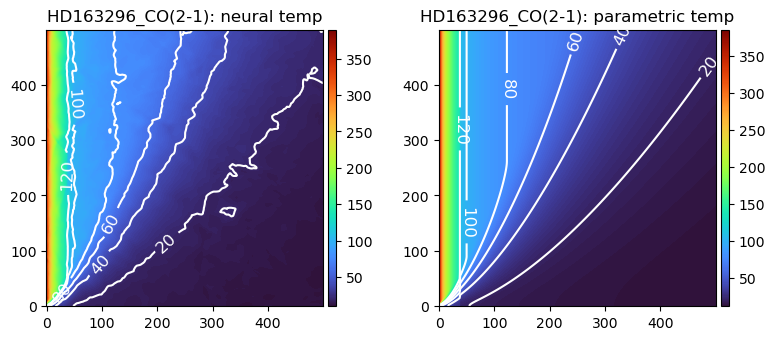

In [123]:
# %matplotlib notebook
levels = [20, 40, 60, 80, 100, 120]
fig, axes = plt.subplots(1, 2, figsize=(8,3.5))
titles = ['{}: neural temp', '{}: parametric temp']
images = [temperature_nn, temperature]
for ax, img, title in zip(axes, images, titles):
    im = ax.imshow(img, origin='lower', cmap='turbo')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='3%', pad=0.05)
    cbar = fig.colorbar(im, cax=cax)
    cp = ax.contour(img, levels, colors='white')
    ax.clabel(cp, levels, inline=1, fontsize=12);
    ax.set_title(title.format(disk.name))
plt.tight_layout()

In [2]:
import jax, jax.numpy as jnp
from functools import partial
from tqdm import trange

# 0) flatten your 2D grid into N×2
grid_coords = jnp.stack((z_disk, r_disk), axis=-1).reshape(-1,2)  # (N,2)
temp_gt     = temperature.reshape(-1)                            # (N,)
sigma_flat  = sigma_map.reshape(-1)                              # (N,)

@jax.tree_util.register_pytree_node_class
class Deformation2D:
    def __init__(self, vec_flat, M=None):
        if vec_flat.ndim == 1:
            assert M is not None
            self.M   = M
            self.vec = vec_flat.reshape(M+1, M+1, 2)
        else:
            self.vec = vec_flat
            self.M   = vec_flat.shape[0] - 1

    def tree_flatten(self):
        return (self.vec,), None
    @classmethod
    def tree_unflatten(cls, aux, children):
        return cls(children[0])

def new_deform(M, dtype=jnp.float32):
    return Deformation2D(jnp.zeros((M+1, M+1, 2), dtype))

# 1) spatial gradient of your MLP w.r.t. (z,r)
def make_spatial_grad_fn(params, apply_fn):
    def T_of_coord(coord):
        return apply_fn({'params': params}, coord)  # scalar
    # returns (B,2): dT/dz, dT/dr
    return jax.jit(jax.vmap(jax.grad(T_of_coord), in_axes=(0,)))

# 2) one‐batch Fisher‐diag
@partial(jax.jit, static_argnums=(4,5,6))
def fisher_diag(deform, params,
                batch_coords,   # (B,2)
                batch_temp,     # (B,)    (unused, we only need ∇T and σ)
                apply_fn,       # predictor.apply
                z_max, r_max,
                sigma,          # (B,)
                λ=1e-6):
    M = deform.M
    B = batch_coords.shape[0]
    # a) spatial grads ∇₍z,r₎T_k  shape (B,2)
    grad_T = make_spatial_grad_fn(params, apply_fn)(batch_coords)

    # b) flatten‐index for the (M+1)x(M+1) grid
    #    and bilinear weights
    u = jnp.clip(batch_coords[:,0]/z_max * M, 0, M-1e-6)
    v = jnp.clip(batch_coords[:,1]/r_max * M, 0, M-1e-6)
    i = jnp.floor(u).astype(int)
    j = jnp.floor(v).astype(int)
    du, dv = u - i, v - j

    w00 = (1-du)*(1-dv)
    w10 =    du *(1-dv)
    w01 = (1-du)*    dv
    w11 =    du *    dv

    # c) per‐sample contribs ∂T/∂z and ∂T/∂r squared, weighted by 1/σ²
    contrib_z = (grad_T[:,0] / sigma)**2  # (B,)
    contrib_r = (grad_T[:,1] / sigma)**2  # (B,)

    # d) for each corner, accumulate wXX * contrib into the flattened grid
    nvert = (M+1)*(M+1)
    def scatter_channel(contrib, weight, di, dj):
        # flatten index
        flat_idx = (i+di)*(M+1) + (j+dj)      # (B,)
        return jax.ops.segment_sum(weight * contrib, flat_idx, nvert)

    Fz00 = scatter_channel(contrib_z, w00, 0, 0)
    Fz10 = scatter_channel(contrib_z, w10, 1, 0)
    Fz01 = scatter_channel(contrib_z, w01, 0, 1)
    Fz11 = scatter_channel(contrib_z, w11, 1, 1)
    Fr00 = scatter_channel(contrib_r, w00, 0, 0)
    Fr10 = scatter_channel(contrib_r, w10, 1, 0)
    Fr01 = scatter_channel(contrib_r, w01, 0, 1)
    Fr11 = scatter_channel(contrib_r, w11, 1, 1)

    # sum all four corners + prior 2λ
    Fz = (Fz00 + Fz10 + Fz01 + Fz11).reshape(M+1, M+1) + 2*λ
    Fr = (Fr00 + Fr10 + Fr01 + Fr11).reshape(M+1, M+1) + 2*λ

    return jnp.stack([Fz, Fr], axis=-1)  # shape (M+1, M+1, 2)

# 3) accumulate over many mini‐batches
M      = temperature.shape[0]
deform = new_deform(M)
F_diag = jnp.zeros_like(deform.vec)

key = jax.random.PRNGKey(0)
N_batches, B = 500, 4096

for _ in trange(N_batches, desc="Accumulating Fisher"):
    key, sub = jax.random.split(key)
    idx = jax.random.choice(sub, grid_coords.shape[0], (B,), replace=False)
    bc  = grid_coords[idx]
    bt  = temp_gt[idx]
    s   = sigma_flat[idx]

    F_diag += fisher_diag(
        deform,
        checkpoint_params,
        bc, bt,
        predictor.apply,
        hparams['z_max'], hparams['r_max'],
        s,
        1e-2
    )

# optional: normalize so magnitudes match your σ_map
F_diag /= (N_batches)

# Laplace covariance & stdev
Σ_diag = 1.0 / F_diag
σ_grid  = jnp.sqrt(Σ_diag)
sigma_show = np.sqrt(np.array(σ_grid[...,0])**2 + np.array(σ_grid[...,1])**2)


# 4) visualize
import matplotlib.pyplot as plt
plt.figure(figsize=(5,4))
plt.imshow(np.array(σ_grid[...,0]), origin='lower', cmap='inferno')
plt.colorbar(label='σ_T from BayesRays')
plt.title("Recovered epistemic uncertainty")
plt.tight_layout()
plt.show()


NameError: name 'z_disk' is not defined

In [ ]:
plt.title("Generated SIGMA")
plt.imshow(sigma_map, origin='lower', cmap='inferno')
plt.colorbar()

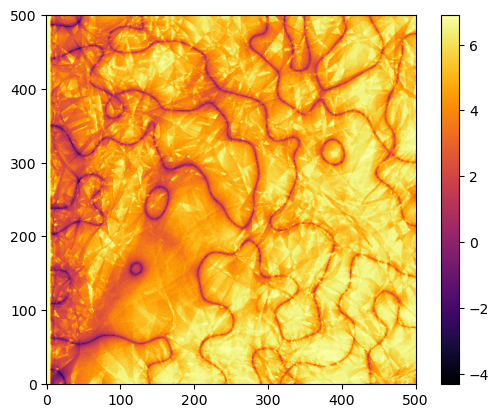

In [126]:
sigma_show = np.sqrt(np.array(σ_grid[...,0])**2 + np.array(σ_grid[...,1])**2)

plt.imshow(np.log(sigma_show), origin='lower', cmap='inferno')
plt.colorbar()

In [103]:
sigma_floor = np.min(sigma_map)   # e.g. 0.01
λ = 1.0/(2 * sigma_floor**2)       # => 1/(2*1e-4)=5000
λ

np.float64(4987.667087512565)